In [2]:
!pip install transformers

  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
    --------------------------------------- 0.3/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 1.7 MB/s eta 0:00:07
   ---- ----------------------------------- 1.3/12.3 MB 2.0 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/12.3 MB 1.8 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.3 MB 2.0 MB/s eta 0:00:06
   ------- -------------------------------- 2.4/12.3 MB 2.0 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.3 MB 2.0 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.3 MB 2.0 MB/s eta 0:00:05
   ----------- ---------------------------- 3.7/12.3 MB 1.9 MB/s eta 0:00:05
   ------------ --------------------------- 3.9/12.3 MB 1.9 MB/s eta 0:00:05
   ------------- -------------------------- 4.2/12.3 MB 1.9 MB/s eta 0:00:05
   ---------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow-skinny 2.20.2 requires protobuf<6,>=3.12.0, but you have protobuf 7.36.1 which is incompatible.
streamlit 1.40.2 requires protobuf<6,>=3.20, but you have protobuf 7.36.1 which is incompatible.


In [1]:
pip install torch torchvision 

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.1 MB 2.4 MB/s eta 0:00:52
   ---------------------------------------- 0.8/124.1 MB 1.6 MB/s eta 0:01:18
   ---------------------------------------- 1.3/124.1 MB 1.7 MB/s eta 0:01:14
    --------------------------------------- 1.8/124.1 MB 2.0 MB/s eta 0:01:01
    --------------------------------------- 2.4/124.1 MB 2.0 MB/s eta 0:01:01
    --------------------------------------- 2.6/124.1 MB 2.0 MB/s eta 0:01:02
    --------------------------------------- 2.9/124.1 MB 1.8 MB/s eta 0:01:07
   - -------------------------------------- 3.4/124.1 MB 1.9 MB/s eta 0:01:04
   - -------------------------------------- 4.2/124.1 MB 2.1 MB/s eta 0:00:58
   - -----------------

In [1]:
# importing the libraries
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [2]:
import os

In [3]:
# Download the correct dataset containing the fer2013.csv file
csv_path = kagglehub.dataset_download("yusufkorayhasdemir/fer2013csv")

# Load the CSV file from the newly downloaded dataset path
df = pd.read_csv(os.path.join(csv_path, 'fer2013.csv'))
display(df.head())

100%|██████████| 96.6M/96.6M [00:00<00:00, 117MB/s]

Extracting files...


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [4]:
df.shape

(35887, 3)

In [5]:
#  checking how many images per emotion class
df['emotion'].value_counts()

,count
emotion,
3,8989
6,6198
4,6077
2,5121
0,4953
5,4002
1,547


In [ ]:
# The dataset only gives numbers (0-6), so I need to know which number means which emotion.
# This mapping comes from the official FER-2013 dataset description.

In [6]:
emotion_labels = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

emotion_labels

{0: 'Angry',
 1: 'Disgust',
 2: 'Fear',
 3: 'Happy',
 4: 'Sad',
 5: 'Surprise',
 6: 'Neutral'}

In [7]:
df.head(2)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training


## Step 4: Turning the pixel column into actual images

Right now each image is just text.. I split that string, tye cast into ints, and reshape it into a 48x48 grid (that's the image size for this dataset).

In [8]:
#creating a user defined function to convert ixel into image

def pixels_to_image(pixel):
    # split the string by spaces, turn into a ints
    pixel_values = pixel.split(' ')
    pixel_values = [int(p) for p in pixel_values]

    # turn the flat list into a 48x48 grid (this is a grayscale image)
    image = np.array(pixel_values).reshape(48, 48)
    return image

In [9]:
# test it on the first row to make sure it works
sample_image = pixels_to_image(df['pixels'][0])
# sample_image.shape
# sample_image = pixels_to_image(df['pixels'][12])

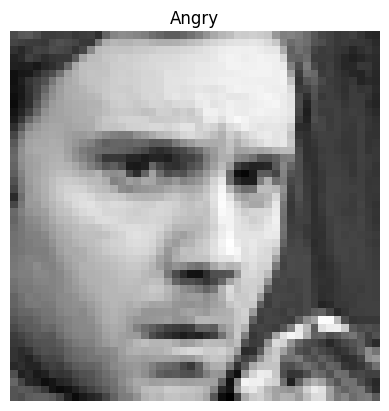

In [10]:
# let's actually SEE it
plt.imshow(sample_image, cmap='gray')
plt.title(emotion_labels[df['emotion'][0]])
plt.axis('off')
plt.show()

In [11]:
sample_image_2 = pixels_to_image(df['pixels'][12])

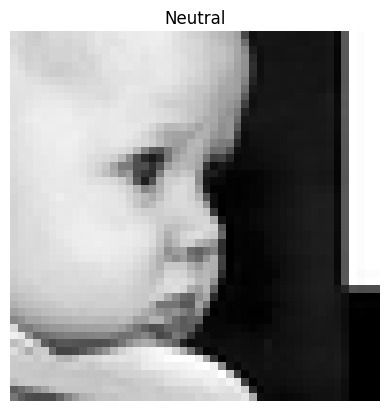

In [12]:
# let's actually SEE it
plt.imshow(sample_image_2, cmap='gray')
plt.title(emotion_labels[df['emotion'][12]])
plt.axis('off')
plt.show()

In [13]:
# apply this to every row in the dataset
df['image'] = df['pixels'].apply(pixels_to_image)

In [14]:
df.head(2)

,emotion,pixels,Usage,image
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,"[[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, ..."
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,"[[151, 150, 147, 155, 148, 133, 111, 140, 170,..."


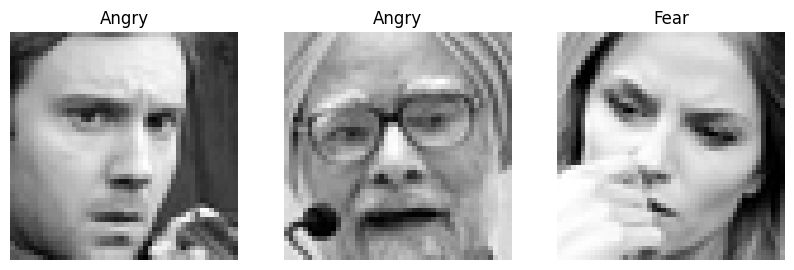

In [15]:
# a few random examples with their labels, just to  check
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(df['image'][i], cmap='gray')
    plt.title(emotion_labels[df['emotion'][i]])
    plt.axis('off')
plt.show()

## Preparing the data for the model
reshape the images so Keras knows they have 1 color channel (grayscale).

In [16]:
# stack all images into one big array, and scale pixel values to 0-1
X = np.stack(df['image'].values)
X = X.astype('float32') / 255.0

# add a channel dimension: (num_images, 48, 48) -> (num_images, 48, 48, 1)
X = X.reshape(-1, 48, 48, 1)
X.shape

(35887, 48, 48, 1)

In [17]:
y = df['emotion'].values
y.shape

(35887,)

In [18]:
# the 'Usage' column already tells us how the dataset should be split
df['Usage'].value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


In [19]:
train = df['Usage'] == 'Training'
validation= df['Usage'] == 'PublicTest'
test = df['Usage'] == 'PrivateTest'

X_train, y_train = X[train], y[train]
X_val, y_val = X[validation], y[validation]
X_test, y_test = X[test], y[test]

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (28709, 48, 48, 1)
Validation: (3589, 48, 48, 1)
Test: (3589, 48, 48, 1)


In [20]:
from tensorflow.keras.utils import to_categorical

# one-hot encode the labels (needed for the softmax output + categorical loss)
num_classes = 7
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

## Step 7: Build the CNN model

I'm using a simple CNN with a few convolution + pooling blocks, then some dense layers at the end. Dropout is added to help prevent overfitting (the model memorizing training data instead of learning general patterns).

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [27]:
model = Sequential([
    # Block 1
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Flatten and classify
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,732,807 (10.42 MB)

 Trainable params: 2,731,911 (10.42 MB)

 Non-trainable params: 896 (3.50 KB)

## Step 8: Compile the model

This just tells Keras how to train — which loss function, which optimizer, what to track.

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 9: Train the model

This is the part that actually takes time. I'm starting with 30 epochs — if I see the validation accuracy stop improving earlier than that, I can lower this number next time.

In [29]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=64
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.2504 - loss: 1.9357 - val_accuracy: 0.3020 - val_loss: 1.7659
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3148 - loss: 1.6648 - val_accuracy: 0.2502 - val_loss: 1.7819
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3637 - loss: 1.5763 - val_accuracy: 0.4146 - val_loss: 1.5069
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3905 - loss: 1.5102 - val_accuracy: 0.4539 - val_loss: 1.4550
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4186 - loss: 1.4443 - val_accuracy: 0.4366 - val_loss: 1.4260
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4413 - loss: 1.3866 - val_accuracy: 0.4531 - val_loss: 1.4136
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4665 - loss: 1.3281 - val_accuracy: 0.4681 - val_loss: 1.4254
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4891 - loss: 1.2806 - val_acc

### Let's plot how training went

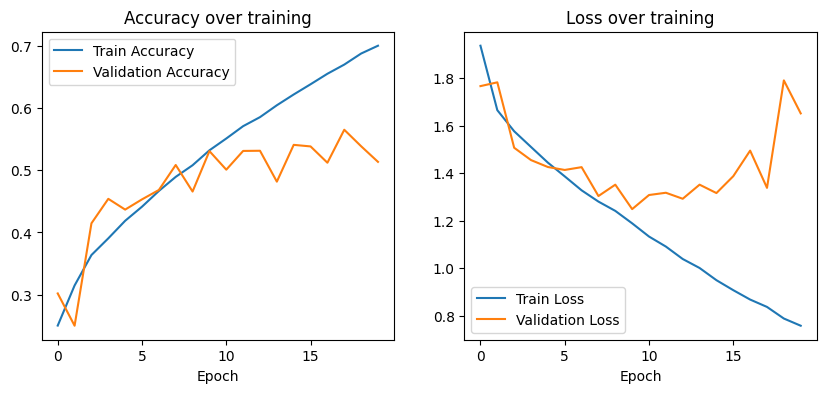

In [30]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.title('Accuracy over training')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('Loss over training')

plt.show()

## Evaluate on the test set

This is the real, honest number I should report — it's data the model never saw during training.

In [31]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f'Test Accuracy: {test_accuracy*100:.2f}%')

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5194 - loss: 1.5676
Test Accuracy: 51.94%


**Note to self:** FER-2013 is a genuinely hard dataset (some images are low quality, and even humans disagree on some labels). A test accuracy somewhere in the 55-70% range is a normal, honest result for a CNN like this — I should NOT be surprised if I don't get 90%+, and I should report whatever number I actually get here, not round it up.

## confusion matrix

In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [33]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


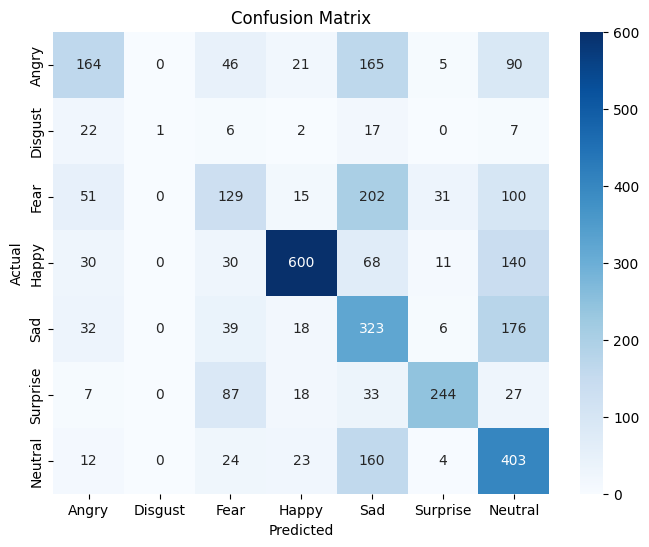

In [34]:
cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(),
            yticklabels=emotion_labels.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
print(classification_report(y_test, y_pred_labels, target_names=emotion_labels.values()))

              precision    recall  f1-score   support

       Angry       0.52      0.33      0.41       491
     Disgust       1.00      0.02      0.04        55
        Fear       0.36      0.24      0.29       528
       Happy       0.86      0.68      0.76       879
         Sad       0.33      0.54      0.41       594
    Surprise       0.81      0.59      0.68       416
     Neutral       0.43      0.64      0.51       626

    accuracy                           0.52      3589
   macro avg       0.62      0.44      0.44      3589
weighted avg       0.57      0.52      0.52      3589



## Saving the trained model

So I can load it later in the Streamlit app without retraining every time.

In [36]:
model.save('emotion_model.h5')
print('Model saved!')

Model saved!


## Try the model on one test image, like a real prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


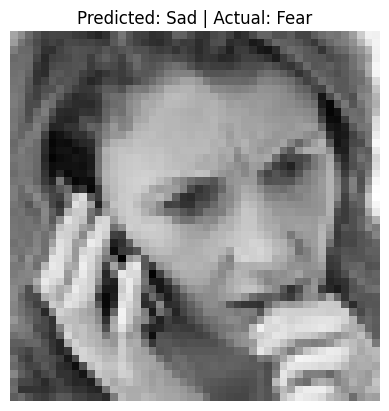

In [40]:
sample_idx = 200
sample = X_test[sample_idx].reshape(1, 48, 48, 1)

prediction = model.predict(sample)
predicted_class = np.argmax(prediction)
actual_class = y_test[sample_idx]

plt.imshow(X_test[sample_idx].reshape(48,48), cmap='gray')
plt.title(f'Predicted: {emotion_labels[predicted_class]} | Actual: {emotion_labels[actual_class]}')
plt.axis('off')
plt.show()

## Conclusion

- Built a CNN from scratch to classify 7 emotions from facial images (FER-2013)
- Used OpenCV's Haar Cascade for face detection instead of dlib (simpler to install, worked fine for this use case)
- Trained with Batch Normalization + Dropout to reduce overfitting
- Final test accuracy: **[fill in my actual number from Step 10 here]**
- Next step: wrap this saved model in a Streamlit app so I can upload a photo and get a live prediction